In [6]:
# -*- coding: utf-8 -*-
"""
无/有向图链接预测评测（按“阈值曲线下的面积”定义）
- 正样本：test_edges
- 负样本（无向）：由 train 节点诱导完全图，去除 train_edges 与 test_edges（无向、无自环）
- 负样本（有向）：由 train 节点诱导有向完全图（u!=v 的有序对），去除 train_edges 与 test_edges（有向、无自环）
- 每个算法需提供：name 属性 与 score_pairs(edge_index) 方法，返回 [0,1] 分数
- 对每个阈值 θ∈[0,1] 计算：
    TP/|P|, FN/|P|, FP/|N|, TN/|N|
  并对四条曲线各自积分（阈值为横轴，比例为纵轴），得到 AUC
"""
# -*- coding: utf-8 -*-
"""
统一评测模块（支持有向 / 无向链接预测）
新版指标：
    - Precision–Recall 曲线（每个算法一条曲线）
    - AP (Average Precision)，即 PR-AUC（sklearn 定义）

删除内容：
    - 不再计算 TP / FP / FN / TN
    - 不再需要 thresholds 参数
    - 不再返回 4 条 AUC 曲线
"""

from dataclasses import dataclass
from typing import Iterable, List, Tuple, Dict, Sequence, Optional
import numpy as np
from tqdm.notebook import tqdm
from sklearn.metrics import precision_recall_curve, average_precision_score

# ============================================================
# edge 相关工具
# ============================================================

Edge = Tuple[int, int]  # 有向表示 (u,v)，无向表示规范化 (min,max)
from matplotlib import pyplot as plt
import matplotlib.font_manager
matplotlib.font_manager._get_fontconfig_fonts.cache_clear()

plt.rcParams["font.family"] = ["serif"]
plt.rcParams["font.serif"] = ["Times New Roman"]
# ---------- 无向 ----------
def _canon_edge_undirected(u: int, v: int) -> Edge:
    if u == v:
        raise ValueError("自环不允许作为边。")
    return (u, v) if u < v else (v, u)

def canon_edges_undirected(edges: Iterable[Tuple[int, int]]) -> List[Edge]:
    out = []
    for u, v in edges:
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        out.append((a, b))
    return sorted(set(out))

def build_negative_edges_from_train_clique_undirected(
    train_edges: Iterable[Tuple[int, int]],
    test_edges: Iterable[Tuple[int, int]],
) -> List[Edge]:
    tr = canon_edges_undirected(train_edges)
    te = canon_edges_undirected(test_edges)
    V_train = sorted(set([u for e in tr for u in e]))
    print(f"[undirected] 训练节点数：{len(V_train)}")

    neg_all = []
    n = len(V_train)
    for i in range(n):
        ui = V_train[i]
        for j in range(i + 1, n):
            vj = V_train[j]
            neg_all.append((ui, vj))

    forbidden = set(tr) | set(te)
    return [e for e in neg_all if e not in forbidden]

# ---------- 有向 ----------
def _canon_edge_directed(u: int, v: int) -> Edge:
    if u == v:
        raise ValueError("自环不允许作为边。")
    return (u, v)

def canon_edges_directed(edges: Iterable[Tuple[int, int]]) -> List[Edge]:
    out = []
    for u, v in edges:
        if u == v:
            continue
        e = (int(u), int(v))
        out.append(e)
    return out

def build_negative_edges_from_train_complete_digraph(
    train_edges: Iterable[Tuple[int, int]],
    test_edges: Iterable[Tuple[int, int]],
) -> List[Edge]:
    tr = canon_edges_directed(train_edges)
    te = canon_edges_directed(test_edges)
    V_train = sorted(set([u for e in tr for u in e]))
    print(f"[directed] 训练节点数：{len(V_train)}")

    neg_all = [(u, v) for u in V_train for v in V_train if u != v]
    forbidden = set(tr) | set(te)
    return [e for e in neg_all if e not in forbidden]

# ---------- array ----------
def edge_array(edges: Sequence[Edge]) -> np.ndarray:
    if len(edges) == 0:
        return np.empty((0, 2), dtype=np.int64)
    arr = np.asarray(edges, dtype=np.int64)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("边应为形状 (E,2)。")
    return arr

# ============================================================
# 评测接口
# ============================================================

class ScoringAlgorithm:
    """算法需实现：
        - 属性 name: str
        - 方法 score_pairs(edge_index) -> np.ndarray[(E,), float] in [0,1]
    """
    name: str
    def score_pairs(self, edge_index: np.ndarray) -> np.ndarray:
        raise NotImplementedError

# ============================================================
# 曲线结构体：仅 PR + AP
# ============================================================

@dataclass
class CurveResult:
    precision: np.ndarray   # (K,)
    recall: np.ndarray      # (K,)
    ap: float               # scalar

# ============================================================
# 评测输出
# ============================================================

@dataclass
class EvalOutput:
    labels: np.ndarray           # (E,)
    edge_index: np.ndarray       # (E,2)
    pr_curves: Dict[str, CurveResult]
    cardinality: Dict[str, int]

# ============================================================
# 主评测逻辑（directed / undirected）
# ============================================================

def evaluate_algorithms(
    train_edges: Iterable[Tuple[int, int]],
    test_edges: Iterable[Tuple[int, int]],
    algorithms: Sequence[ScoringAlgorithm],
    test_neg_edges: Optional[Iterable[Tuple[int, int]]] = None,
    directed: bool = True,
    num_blocks: int = 100,
) -> EvalOutput:

    # ----- 构造正负样本 -----
    assert directed is True, "目前仅支持有向图评测。"
    te = test_edges
    if test_neg_edges is not None:
        neg = test_neg_edges
        print(f"[directed] 正样本 {len(te)} 条，负样本（提供） {len(neg)} 条")
    else:
        raise NotImplementedError("目前必须提供负样本列表。")
    print(f"[directed] 正样本 {len(te)} 条，负样本 {len(neg)} 条")


    pos_arr = edge_array(te)
    neg_arr = edge_array(neg)
    edge_index = np.concatenate([pos_arr, neg_arr], axis=0)
    labels = np.concatenate([
        np.ones(len(pos_arr), dtype=np.int8),
        np.zeros(len(neg_arr), dtype=np.int8)
    ], axis=0)

    # ----- 按算法计算 PR + AP -----
    pr_curves: Dict[str, CurveResult] = {}
    E = edge_index.shape[0]
    num_blocks = max(1, int(num_blocks))

    for algo in algorithms:
        scores_list = []
        for b in tqdm(range(num_blocks), desc=f"Evaluating {algo.name}"):
            start = (E * b) // num_blocks
            end   = (E * (b + 1)) // num_blocks
            block = edge_index[start:end]
            scores_list.append(algo.score_pairs(block))

        scores = np.concatenate(scores_list, axis=0).astype(np.float64)

        if scores.shape != (E,):
            raise ValueError(f"{algo.name}: score_pairs 返回形状应为 (E,)")

        precision, recall, _ = precision_recall_curve(labels, scores)
        ap = float(average_precision_score(labels, scores))
        
        pr_curves[algo.name] = {
            "precision": precision,
            "recall": recall,
            "ap": ap,
        }

    card = {
        "P": int(np.sum(labels == 1)),
        "N": int(np.sum(labels == 0)),
        "E_total": int(labels.shape[0]),
    }

    return EvalOutput(
        labels=labels,
        edge_index=edge_index,
        pr_curves=pr_curves,
        cardinality=card,
    )




In [7]:
import gensim
import torch
import sys
from headnet_evaluation_utils import read_edgelist_our, load_embedding_for_evaluation, get_scores

# -----------------------------
# 可选：基于节点 embedding 的余弦相似度 -> 概率映射打分器
# -----------------------------
class LF_Scorer(ScoringAlgorithm):
    """
    示例：给定节点 embedding，使用余弦相似度经温度缩放映射到 [0,1]。
    score(u,v) = sigmoid( (cos(u,v) - bias) / tau )
      - tau: 温度，越小越陡
      - bias: 偏置，用于校准分数分布
    """
    def __init__(self, path: str, **kwargs):
        self.name = "ours_oi"
        data = torch.load(path)  
        self.locations = data['locations']
        self.bucket_tensor = data['bucket']
        self.distance_lookup_table = data['table']
        self.in_degree = data['in_degree']
        self.out_degree = data['out_degree']
        self.gamma = data['gamma']
        self.alpha = data['alpha']
        self.eps = data['eps']

    def p_test(self, dis, ig1, ig2):
        deg1, deg2 = self.out_degree[ig1], self.in_degree[ig2]   
        ap = (deg1+1)*(deg2+1)
        aa = (dis+self.eps)/torch.log(ap)
        return 1/(1+aa**self.gamma/self.alpha)

    def score_pairs(self, edge_index: np.ndarray) -> np.ndarray:
        assert edge_index.ndim == 2 and edge_index.shape[1] == 2
        
        edge_index = torch.tensor(edge_index)
        node1 = self.bucket_tensor[edge_index[:, 0]]
        node2 = self.bucket_tensor[edge_index[:, 1]]
        
        v1 = self.locations[node1]
        v2 = self.locations[node2]
        dis = self.distance_lookup_table[torch.bitwise_xor(v1, v2)].float()
        scores = self.p_test(torch.mean(dis, dim=-1), node1, node2)
        return scores.numpy()


class LF_Scorer_HT(ScoringAlgorithm):
    """
    示例：给定节点 embedding，使用余弦相似度经温度缩放映射到 [0,1]。
    score(u,v) = sigmoid( (cos(u,v) - bias) / tau )
      - tau: 温度，越小越陡
      - bias: 偏置，用于校准分数分布
    """
    def __init__(self, path: str, **kwargs):
        self.name = "ours_oiht"
        data = torch.load(path)  
        self.locations = data['locations']
        self.bucket_tensor = data['bucket']
        self.distance_lookup_table = data['table']
        self.in_degree = data['in_degree']
        self.out_degree = data['out_degree']
        self.gamma = data['gamma']
        self.alpha = data['alpha']
        self.eps = data['eps']

    def p_test(self, dis, ig1, ig2):
        deg1, deg2 = self.out_degree[ig1], self.in_degree[ig2]   
        ap = (deg1+1)*(deg2+1)
        aa = (dis+self.eps)/torch.log(ap)
        return 1/(1+aa**self.gamma/self.alpha)

    def score_pairs(self, edge_index: np.ndarray) -> np.ndarray:
        assert edge_index.ndim == 2 and edge_index.shape[1] == 2
        
        edge_index = torch.tensor(edge_index)
        node1 = self.bucket_tensor[edge_index[:, 0]]
        node2 = self.bucket_tensor[edge_index[:, 1]]
        
        v1 = self.locations[0][node1]
        v2 = self.locations[1][node2]
        dis = self.distance_lookup_table[torch.bitwise_xor(v1, v2)].float()
        scores = self.p_test(torch.mean(dis, dim=-1), node1, node2)
        return scores.numpy()

class NERD_Scorer(ScoringAlgorithm):
    def __init__(self, hub_path: str, aut_path: str, **kwargs):
        self.name = "nerd"
        hub = self.read_w2v_emb(hub_path, binary=False)
        aut = self.read_w2v_emb(aut_path, binary=False)

        # gensim KeyedVectors
        node_keys = hub.index_to_key
        node_ids = sorted(map(int, node_keys))   # 转为 int，用于 lookup

        self.max_id = max(node_ids)

        # 构建 lookup: int_node_id -> row index
        self.lookup = np.full(self.max_id + 1, -1, dtype=np.int32)
        for row, nid in enumerate(node_ids):
            self.lookup[nid] = row

        # embedding 矩阵对齐
        dim = hub.get_vector(node_keys[0]).shape[0]
        self.hub = np.zeros((len(node_ids), dim), dtype=np.float32)
        self.aut = np.zeros_like(self.hub)

        for row, nid in enumerate(node_ids):
            k = str(nid)
            self.hub[row] = hub[k]
            self.aut[row] = aut[k]

    def sigmoid(self, x):
        out = np.empty_like(x)

        pos = x >= 0
        neg = ~pos

        out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
        exp_x = np.exp(x[neg])
        out[neg] = exp_x / (1.0 + exp_x)

        return out

    
    def read_w2v_emb(self, file_path, binary):
        return gensim.models.KeyedVectors.load_word2vec_format(file_path, binary=0)
    
    def score_pairs(self, edge_index: np.ndarray) -> np.ndarray:
        assert edge_index.ndim == 2 and edge_index.shape[1] == 2
        
        scores = self.sigmoid(
            np.sum(
                self.hub[self.lookup[edge_index[:, 0]]] *
                self.aut[self.lookup[edge_index[:, 1]]],
                axis=-1
            )
        )
        
        return scores
class HEADNET_Scorer(ScoringAlgorithm):
    def __init__(self, path: str):
        self.name = "headnet"
        self.embedding = load_embedding_for_evaluation('klh', path)


    def negval_to_score_exp(
        self, x, tau=None, clip_quantile=0.99, eps=1e-12
    ):
        """
        将非正数 x 映射到 (0,1]，使用 s = exp(x / tau)

        x: np.ndarray 形状 (N,)
            通常为负相似度、负损失等
        tau: float or None
            衰减尺度，若为 None，则取 -median(x)
        clip_quantile: float
            裁剪尾部，避免极端值导致 exp 下溢
        """
        x = torch.as_tensor(x, dtype=torch.float64)

        # 负值右侧尾部裁剪（例如最小的 1%）
        if clip_quantile is not None:
            q = torch.quantile(x, 1 - clip_quantile)   # 注意这里是右尾
            x = torch.maximum(x, q)

        if tau is None:
            tau = -torch.median(x)     # 使 x/tau ≈ O(1)
        tau = max(float(tau), eps)

        s = torch.exp(x / tau)
        return s.numpy()

    def score_pairs(self, edge_index: np.ndarray) -> np.ndarray:
        assert edge_index.ndim == 2 and edge_index.shape[1] == 2
        
        ori_scores = get_scores(self.embedding, edge_index, 'klh')
        # scores = self.negval_to_score_exp(ori_scores, tau=None, clip_quantile=0.99, eps=1e-12)
        
        return ori_scores
    
    
class NODE2KET_Scorer(ScoringAlgorithm):
    def __init__(self, test_pos_scores_path: str, test_neg_scores_path: str):
        self.name = "node2ket"
        self.test_pos_scores = np.load(test_pos_scores_path)
        self.test_neg_scores = np.load(test_neg_scores_path)


    def log1p_mapping(self, x: np.ndarray, label: str):
        """
        将输入 ndarray 映射到 [0, 1]，使用 Log1p 变换。
        要求：若 min(x) < -1e-3 则报错（说明含有真实负值）
        """
        x = np.asarray(x)

        mn = np.min(x)
        if mn < -1e-3:
            raise ValueError(f"Detected real negative values: min={mn} at {label} scores.")

        # 修正微小浮点误差
        if mn < 0:
            x = x - mn      # 将 min 拉到 0（误差 < 1e-3 时安全）

        # Log1p 变换
        y = np.log1p(x)

        # 映射到 [0, 1]
        y = y / np.max(y) if np.max(y) > 0 else y

        return y


    def score_pairs(self, edge_index: np.ndarray) -> np.ndarray:
        assert edge_index.ndim == 2 and edge_index.shape[1] == 2
        
        if edge_index.shape[0] == self.test_pos_scores.shape[0] + self.test_neg_scores.shape[0] :
            return np.concatenate([self.test_pos_scores, self.test_neg_scores])
        else:
            raise ValueError(f"输入的 edge_index 行数与正+负样本数不匹配。存储的正样本数为 {self.test_pos_scores.shape[0]}，负样本数为 {self.test_neg_scores.shape[0]}，加和为 {self.test_pos_scores.shape[0] + self.test_neg_scores.shape[0]}，而输入的 edge_index 行数为 {edge_index.shape[0]}。")


In [8]:
import torch
def get_edges(dataset, ratio):
    data = torch.load(f"/home/gaochi/leaf_matching/datasets/{dataset}/split/split_dict_{ratio}.pt")
    train_edges = data['train']['edge'].numpy()
    test_pos_edges = data['test']['edge'].numpy()
    test_neg_edges = data['test']['edge_neg'].numpy()
    # print(f"Dataset: {dataset}, Ratio: {ratio} -- Train edges: {train_edges.shape}, Test pos edges: {test_pos_edges.shape}, Test neg edges: {test_neg_edges.shape}")
    return train_edges, test_pos_edges, test_neg_edges


In [ ]:
datasets = ['cora', 'male']
split_ratios = [0.3, 0.6, 0.9]
seed = 1
import os
results = torch.load(f'./results/eval_prauc.pt') if os.path.exists(f'./results/eval_prauc.pt') else {}

for dataset in datasets:    
    for ratio in split_ratios:
        # if (dataset, ratio) in results:
        #     print(f"Skipping dataset={dataset}, ratio={ratio:.1f} as results already exist.")
        #     continue
        
        # 1) 获得数据集
        train_edges, test_edges, test_neg_edges = get_edges(dataset, ratio)

        # 2) 初始化算法
        ours_oi = LF_Scorer(
            path=f'/home/gaochi/leaf_matching/logs_oi/{dataset}/scores/s{seed}-r{ratio}/emb.pt'
        )
        ours_oiht = LF_Scorer_HT(
            path=f'/home/gaochi/leaf_matching/logs_ht_oi/{dataset}/scores/s{seed}-r{ratio}/emb.pt'
        )
        
        nerd = NERD_Scorer(
            hub_path=f"/home/gaochi/LF_baseline/nerd/emb/{dataset}/hub_r{ratio}_s{seed}.txt", 
            aut_path=f"/home/gaochi/LF_baseline/nerd/emb/{dataset}/aut_r{ratio}_s{seed}.txt"
        )
        headnet = HEADNET_Scorer(
            path=f'/home/gaochi/LF_baseline/HEADNET/embeddings/{dataset}/r{ratio}_s{seed}/'
        )
        node2ket = NODE2KET_Scorer(
            test_pos_scores_path=f'/home/gaochi/LF_baseline/any2ket_pybind/logs/{dataset}/r{ratio}-s{seed}/pos.npy',
            test_neg_scores_path=f'/home/gaochi/LF_baseline/any2ket_pybind/logs/{dataset}/r{ratio}-s{seed}/neg.npy',
        )
        
        out = evaluate_algorithms(
            train_edges=train_edges,
            test_edges=test_edges,
            test_neg_edges=test_neg_edges,
            algorithms=[ours_oi, ours_oiht, nerd, headnet, node2ket],
            directed=True,
            num_blocks=1
        )

        results[(dataset, ratio)] = out
        
        # 4) 打印结果摘要
        print(f"finished evaluation for dataset={dataset}, ratio={ratio:.1f}")
        print(f"AP scores:")
        for name in ['ours_oi', 'ours_oiht', 'nerd', 'headnet']: # , 'node2ket']:
            res = out.pr_curves[name]
            print(f"  {name}: {res['ap']:.6f}")

torch.save(results, f'./results/eval_prauc.pt')

FileNotFoundError: [Errno 2] No such file or directory: '/home/gaochi/leaf_matching/datasets/coramale/split/split_dict_0.3.pt'

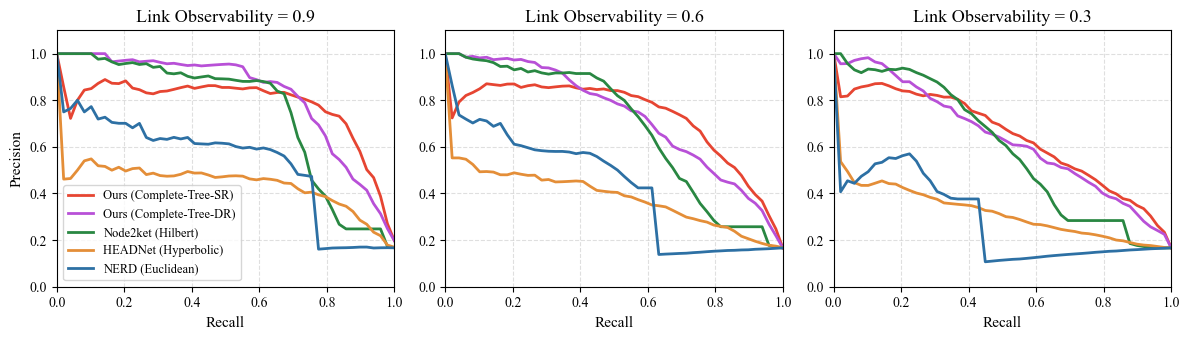

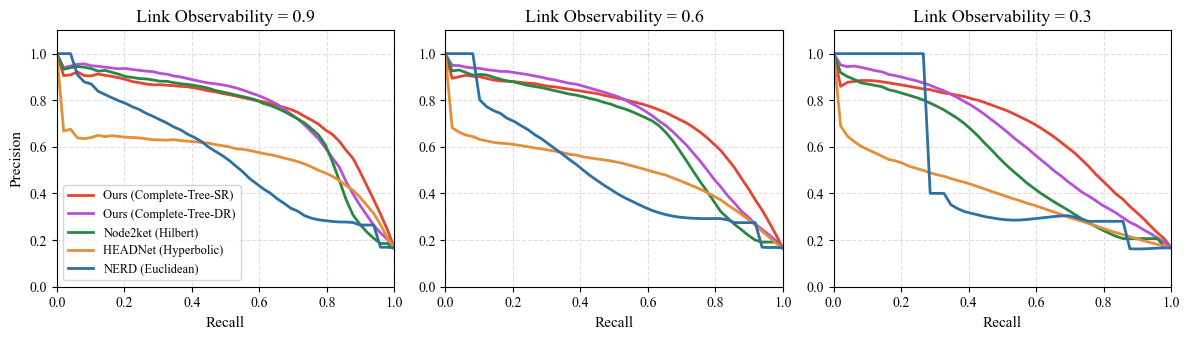

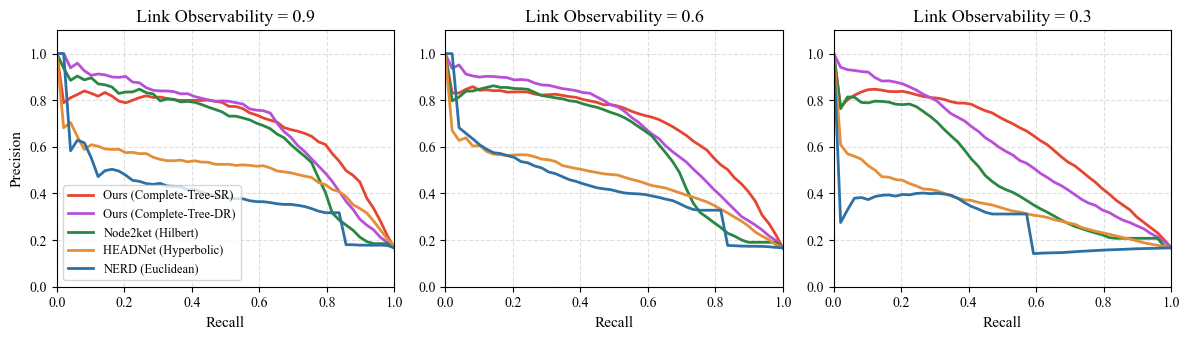

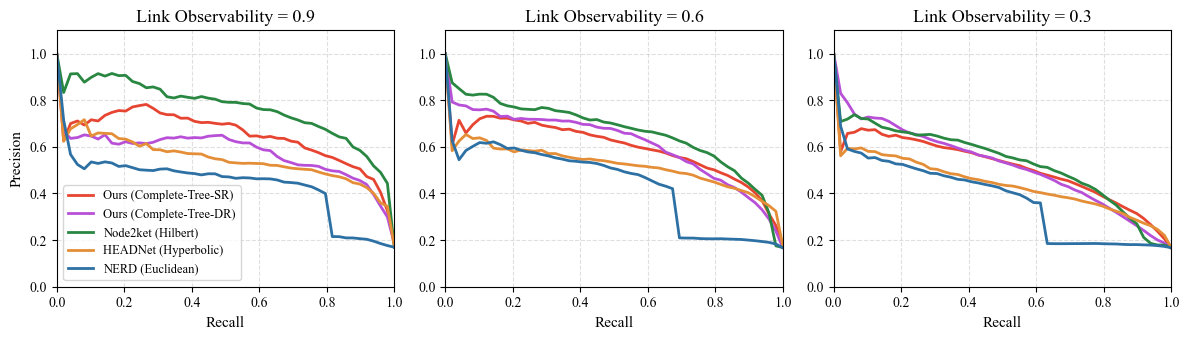

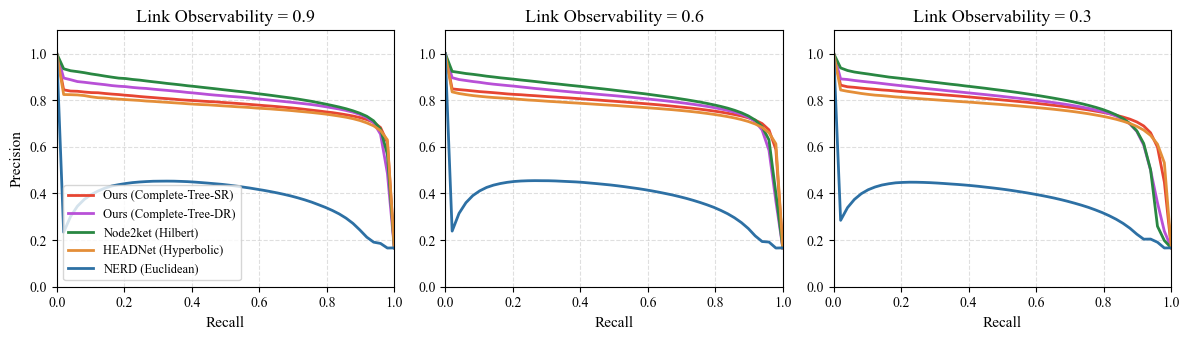

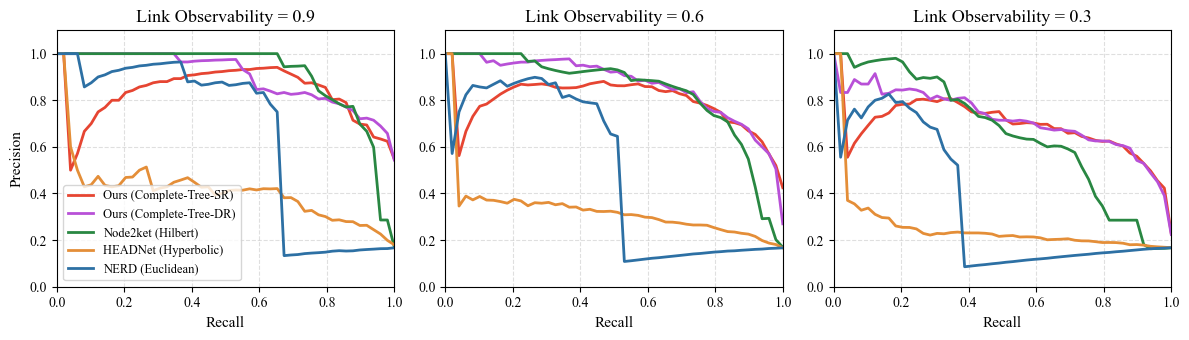

In [20]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import torch

algo_disp = {
    'ours':         'Ours (Complete-Tree)',
    'node2ket': 'Node2ket (Hilbert)',
    'headnet':      'HEADNet (Hyperbolic)',
    'ours_oi':      'Ours (Complete-Tree-SR)',
    'ours_oiht':   'Ours (Complete-Tree-DR)',
    'nerd':         'NERD (Euclidean)',
}


def smooth_pr_curve(precision, recall, num=200):
    recall_new = np.linspace(0, 1, num)
    f = interp1d(recall, precision, kind="previous", fill_value="extrapolate")
    precision_new = f(recall_new)
    return precision_new, recall_new


def plot_pr_tm_panel(results, algorithms=('ours', 'nerd', 'headnet', 'node2ket')):
    """
    精简版：
    仅绘制每个 dataset × ratio 的 PR 曲线（1 行）
    """
    colors = {
        algorithms[0]: '#e64532',
        algorithms[1]: '#b850d7',
        algorithms[2]: '#298742',
        algorithms[3]: '#e48e38',
        algorithms[4]: '#2d70a4',
    }
    linestyles = {algo: "-" for algo in algorithms}

    datasets = sorted(set(k[0] for k in results.keys()))
    ratios   = sorted(set(k[1] for k in results.keys()), reverse=True)

    # 仅 1 行（每 dataset 显示为一行 PR）
    n_rows = len(datasets)
    n_cols = len(ratios)

    for dataset in datasets:

        fig, axes = plt.subplots(
            1, n_cols,
            figsize=(4 * n_cols, 3.5 * 1),
            squeeze=False
        )

        # leave some vertical space below the title for padding
        fig.tight_layout(rect=[0, 0, 1, 0.95])
    
        for rj, ratio in enumerate(ratios):

            out = results[(dataset, ratio)]

            # ========== Row: PR 曲线 ==========
            ax_pr = axes[0][rj]
            for algo in algorithms:
                pr_res = out.pr_curves[algo]
                precision = pr_res['precision']
                recall = pr_res['recall']
                ap = pr_res['ap']

                precision, recall = smooth_pr_curve(precision, recall, num=50)
                
                ax_pr.plot(
                    recall, precision,
                    label=f"{algo_disp[algo]}",
                    color=colors[algo],
                    linestyle=linestyles[algo],
                    linewidth=2
                )

            ax_pr.set_xlim(0, 1.0)
            ax_pr.set_ylim(0, 1.1)
            ax_pr.grid(True, linestyle="--", alpha=0.4)

            ax_pr.set_title(f"Link Observability = {ratio}", fontsize=13)
            ax_pr.set_xlabel("Recall", fontsize=11)
            if rj == 0:
                ax_pr.set_ylabel(f"Precision", fontsize=11)

            # PR 行的 legend 放在第一行最后一个 subplot
            if rj == 0:
                ax_pr.legend(loc="lower left", fontsize=9)

        plt.tight_layout()
        fig.savefig("dir_pr_curves_"+dataset+".pdf", dpi=300)

        plt.show()
    
results = torch.load(f'./results/eval_prauc.pt')
plot_pr_tm_panel(results, algorithms=('ours_oi', 'ours_oiht', 'node2ket', 'headnet', 'nerd'))